In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import Dataset, DataLoader, random_split

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns

import os
from PIL import Image

import warnings
# filter warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm

In [2]:
# Визначення трансформацій
transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Клас для кастомного набору даних
class CustomTestDataset(Dataset):
    def __init__(self, directory, transform=None):
        self.directory = directory
        self.transform = transform
        self.images = []

        # Завантаження зображень
        for filename in os.listdir(directory):
            img_path = os.path.join(directory, filename)
            if os.path.isfile(img_path):
                self.images.append(img_path)  # Додаємо шлях до зображення

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = Image.open(img_path).convert('RGB')  # Конвертація в RGB
        if self.transform:
            image = self.transform(image)  # Застосування трансформацій
        return image
        # Завантаження тренувального набору
train_dir = '/kaggle/input/datasets/imsparsh/flowers-dataset/train'
train_data = datasets.ImageFolder(train_dir, transform=transform)

# Завантаження тестового набору
test_dir = '/kaggle/input/datasets/imsparsh/flowers-dataset/test'
test_dataset = CustomTestDataset(test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Розділення тренувального набору на тренувальний та валідаційний
train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size
train_dataset, val_dataset = random_split(train_data, [train_size, val_size])

# Створення завантажувачів даних
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# Виведення інформації про набори даних
print(f"Кількість класів: {len(train_data.classes)}")
print(f"Класи: {train_data.classes}")
print(f"Розмір тренувального набору: {len(train_dataset)}")
print(f"Розмір валідаційного набору: {len(val_dataset)}")
print(f"Розмір тестового набору: {len(test_dataset)}")  # Зміна тут

# Перевірка балансу класів
class_counts = {class_name: 0 for class_name in train_data.classes}
for _, label in train_data.samples:
    class_counts[train_data.classes[label]] += 1

print("\nРозподіл класів у тренувальному наборі:")
for class_name, count in class_counts.items():
    print(f'{class_name}: {count}')

# Виведення розміру тестового набору
print(f"Розмір тестового набору: {len(test_dataset)}")

Кількість класів: 5
Класи: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Розмір тренувального набору: 2196
Розмір валідаційного набору: 550
Розмір тестового набору: 924

Розподіл класів у тренувальному наборі:
daisy: 501
dandelion: 646
rose: 497
sunflower: 495
tulip: 607
Розмір тестового набору: 924


In [3]:
# Завантаження моделі без попередньо навчених ваг
model = models.resnet18(weights=None)

# Заморожування параметрів моделі
for param in model.parameters():
    param.requires_grad = False

# Заміна останнього повнозв'язного шару під кількість класів
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(train_data.classes))

# Дозволяємо навчати тільки останній шар
for param in model.fc.parameters():
    param.requires_grad = True

# Перенесення моделі на GPU, якщо доступно
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

num_epochs = 5
best_val_loss = float('inf')
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    _, predicted = torch.max(outputs.data, 1)
total += labels.size(0)
correct += (predicted == labels).sum().item()

train_loss = running_loss / len(train_loader)
train_accuracy = correct / total
train_losses.append(train_loss)
train_accuracies.append(train_accuracy)

# Валідація
model.eval()
val_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        val_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

val_loss /= len(val_loader)
val_accuracy = correct / total
val_losses.append(val_loss)
val_accuracies.append(val_accuracy)
print(f'Epoch {epoch+1}/{num_epochs}:')
print(f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}')
print(f'Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')

if val_loss < best_val_loss:
    best_val_loss = val_loss
    torch.save(model.state_dict(), '/kaggle/working/best_model.pth')

100%|██████████| 69/69 [01:07<00:00,  1.03it/s]


Epoch 5/5:
Train Loss: 1.3354, Train Accuracy: 0.5000
Val Loss: 1.3320, Val Accuracy: 0.4582


In [5]:
def visualize_predictions(model, dataloader, class_names, num_images=5):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure(figsize=(15, 10))

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images // 2 + 1, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}\ntrue: {class_names[labels[j]]}')

                # Денормалізація зображення для відображення
                inv_normalize = transforms.Normalize(
                    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
                    std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
                )

                inp = inv_normalize(inputs.cpu()[j]).numpy().transpose((1, 2, 0))
                inp = np.clip(inp, 0, 1)

                plt.imshow(inp)

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    plt.tight_layout()
                    plt.show()
                    return

    model.train(mode=was_training)
    plt.tight_layout()
    plt.show()

In [6]:
def plot_training_metrics(train_losses, train_accuracies, val_losses, val_accuracies):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-', label='Training Loss')
    plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_accuracies, 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

Validation Loss: 0.0688
Validation Accuracy: 0.4582
F1 Score: 0.4147


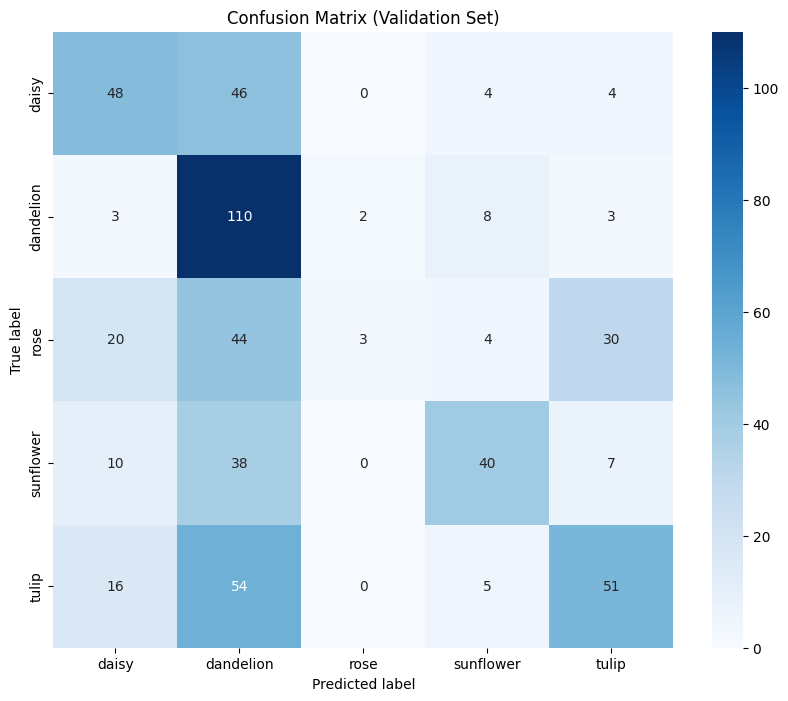

In [7]:
# Завантажуємо найкращу модель перед оцінюванням
model.load_state_dict(torch.load('/kaggle/working/best_model.pth'))
model.eval()

# =======================================
# 1. Оцінка на validation set
# =======================================
all_labels = []
all_preds = []
val_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        val_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        val_loss /= len(val_loader)
val_accuracy = correct / total
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f'Validation Loss: {val_loss:.4f}')
print(f'Validation Accuracy: {val_accuracy:.4f}')
print(f'F1 Score: {f1:.4f}')

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_data.classes,
    yticklabels=train_data.classes
)
plt.title('Confusion Matrix (Validation Set)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

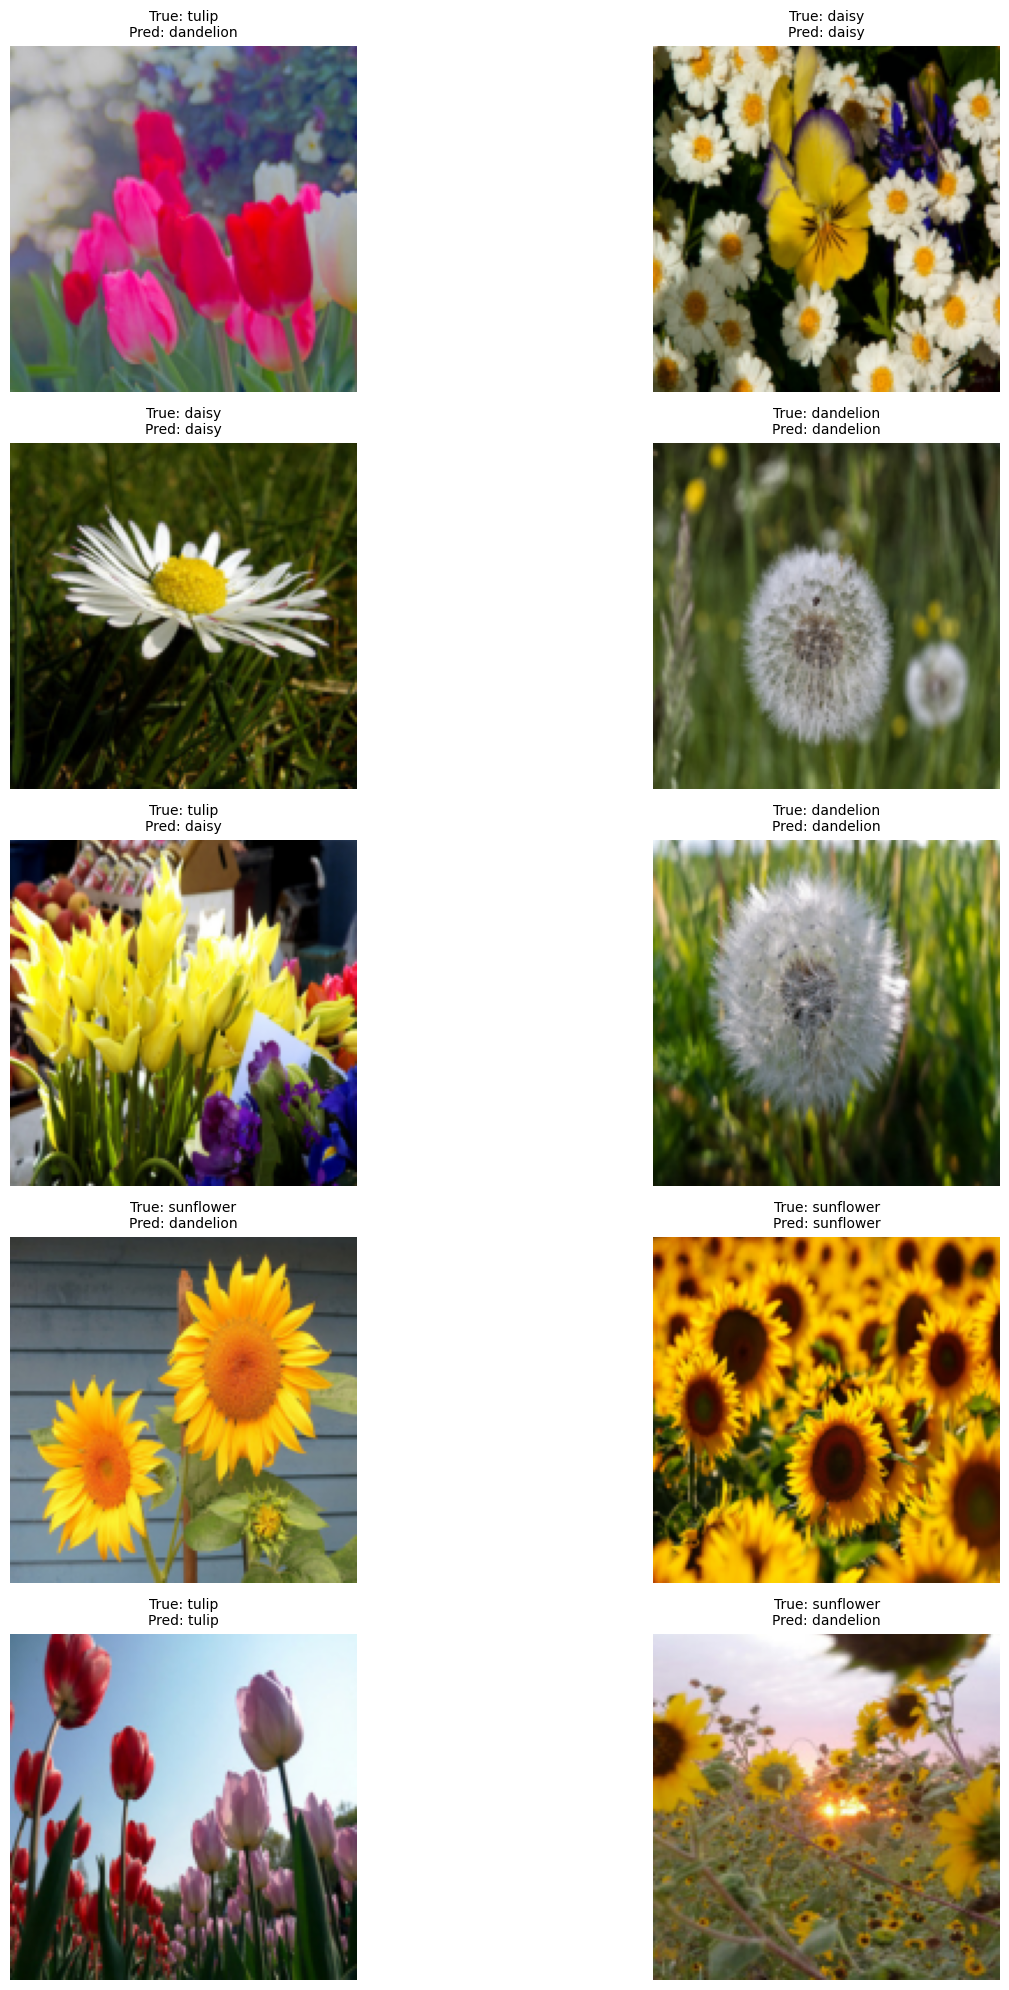

In [8]:
# Вивести 10 зображень з validation set:
# справжній клас + прогнозований клас
num_images = 10
shown = 0

fig = plt.figure(figsize=(16, 20))

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        for j in range(inputs.size(0)):
            shown += 1
            ax = plt.subplot(5, 2, shown)
            ax.axis('off')
            ax.set_title(
                f"True: {train_data.classes[labels[j].item()]}\n"
                f"Pred: {train_data.classes[preds[j].item()]}",
                fontsize=10
            )

            # Денормалізація
            inv_normalize = transforms.Normalize(
                mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
                std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
            )

            img = inv_normalize(inputs[j].cpu()).numpy().transpose((1, 2, 0))
            img = np.clip(img, 0, 1)

            plt.imshow(img)

            if shown == num_images:
                plt.tight_layout()
                plt.show()
                break

        if shown == num_images:
            break